In [4]:
library(readxl)
library(devtools)
library(dplyr)
library(ggbasketball)
library(orthopolynom)
library(mvtnorm)
library(combinat)
library(lattice)
library(gridExtra)
library(grid) 
library(patchwork)

player_list = c('curry', 'jordan', 'james')
plot_data_intensity <- data.frame()
plot_data_probability <- data.frame()
plot_data_RR <- data.frame()
for(player in player_list)
{
    source('../Code/basket_func_same.R')
    
    load(file=sprintf('../Data/%s_homelevel_theta.RData',player))  # Theta.result: 15000*15*7
    
    # data(shotdata)
    # head(shotdata)
    # dim(shotdata)


    ## Load Model Fitting Results
    ########################################################
    a = 0.25
    d = 2
    b=1.5
    n = GP.eigen.degree(0.8,a=a,b=b,d=d)$n
    L = 15
    
    sgrid=as.matrix(expand.grid(seq(-1,1,length=50),seq(-1,1,length=40)))
    newgrid=matrix(0,nrow=nrow(sgrid),ncol=2)
    newgrid[,1]=300*(sgrid[,1]+1)
    newgrid[,2]=235*(sgrid[,2]+1)
    amat = GP.eigen.funcs(sgrid, n=n, a=a, b=b)
    home_miss_strong = away_miss_strong = home_made_strong = away_made_strong = matrix(0, nrow = nrow(amat), ncol=1)
    home_miss_weak = away_miss_weak = home_made_weak = away_made_weak = matrix(0, nrow = nrow(amat), ncol=1)
    for(i in 1:5000){
      temp.theta = Theta.result[(10000+i),,]
      
      home_miss_strong = home_miss_strong + exp(amat%*%(temp.theta[,1]+temp.theta[,2] + temp.theta[, 4]))
      away_miss_strong = away_miss_strong+exp(amat%*%(temp.theta[,1]+temp.theta[,3]+ temp.theta[, 4]))
      home_made_strong = home_made_strong+exp(amat%*%(temp.theta[,1]+temp.theta[,5]+temp.theta[,7]))
      away_made_strong = away_made_strong+exp(amat%*%(temp.theta[,1]+temp.theta[,6]+temp.theta[,7]))
      home_miss_weak = home_miss_weak+exp(amat%*%(temp.theta[,1]+temp.theta[,2]))
      away_miss_weak = away_miss_weak+exp(amat%*%(temp.theta[,1]+temp.theta[,3]))
      home_made_weak = home_made_weak+exp(amat%*%(temp.theta[,1]+temp.theta[,5]))
      away_made_weak = away_made_weak+exp(amat%*%(temp.theta[,1]+temp.theta[,6]))
    }
    home_miss_strong = home_miss_strong/5000
    home_made_strong = home_made_strong/5000
    away_miss_strong = away_miss_strong/5000
    away_made_strong = away_made_strong/5000
    home_miss_weak = home_miss_weak/5000
    home_made_weak = home_made_weak/5000
    away_miss_weak = away_miss_weak/5000
    away_made_weak = away_made_weak/5000
    
    Miss_home_strong = sqrt(home_miss_strong)
    Miss_away_strong = sqrt(away_miss_strong)
    Made_home_strong = sqrt(home_made_strong)
    Made_away_strong = sqrt(away_made_strong)
    Miss_home_weak = sqrt(home_miss_weak)
    Miss_away_weak = sqrt(away_miss_weak)
    Made_home_weak = sqrt(home_made_weak)
    Made_away_weak = sqrt(away_made_weak)
    my.min=min(Miss_home_strong,Miss_away_strong, Made_home_strong, Made_away_strong,
               Miss_home_weak,Miss_away_weak, Made_home_weak, Made_away_weak)
    my.max=max(Miss_home_strong,Miss_away_strong, Made_home_strong, Made_away_strong,
               Miss_home_weak,Miss_away_weak, Made_home_weak, Made_away_weak)

    ##p(made|s)*p(s)
    home_prob_strong = home_made_strong/sum(home_made_strong + home_miss_strong)
    away_prob_strong = away_made_strong/sum(away_made_strong + away_miss_strong)
    home_prob_weak = home_made_weak/sum(home_made_weak + home_miss_weak)
    away_prob_weak = away_made_weak/sum(away_made_weak + away_miss_weak)
    # 

    ##give strong, risk of home vs away
    strong_risk_home_away = home_prob_strong/away_prob_strong
    weak_risk_home_away = home_prob_weak/away_prob_weak
    ##given home, risk of strong vs weak
    home_risk_strong_weak = home_prob_strong/home_prob_weak
    away_risk_strong_weak = away_prob_strong/away_prob_weak

    # strong_riskcred_home_away = weak_riskcred_home_away = home_riskcred_strong_weak = away_riskcred_strong_weak = NULL
    
    # for(i in 1:5000){
    #   temp.theta=Theta.result[(10000+i),,]
    #   thome_miss_strong = exp(amat%*%(temp.theta[,1]+temp.theta[,2] + temp.theta[, 4]))
    #   taway_miss_strong = exp(amat%*%(temp.theta[,1]+temp.theta[,3]+ temp.theta[, 4]))
    #   thome_made_strong = exp(amat%*%(temp.theta[,1]+temp.theta[,5]+temp.theta[,7]))
    #   taway_made_strong = exp(amat%*%(temp.theta[,1]+temp.theta[,6]+temp.theta[,7]))
    #   thome_miss_weak = exp(amat%*%(temp.theta[,1]+temp.theta[,2]))
    #   taway_miss_weak = exp(amat%*%(temp.theta[,1]+temp.theta[,3]))
    #   thome_made_weak = exp(amat%*%(temp.theta[,1]+temp.theta[,5]))
    #   taway_made_weak = exp(amat%*%(temp.theta[,1]+temp.theta[,6]))
      
    #   thome_prob_strong = thome_made_strong/sum(thome_made_strong + thome_miss_strong)
    #   taway_prob_strong = taway_made_strong/sum(taway_made_strong + taway_miss_strong)
    #   thome_prob_weak = thome_made_weak/sum(thome_made_weak + thome_miss_weak)
    #   taway_prob_weak = taway_made_weak/sum(taway_made_weak + taway_miss_weak)
      
    #   strong_riskcred_home_away=cbind(strong_riskcred_home_away, thome_prob_strong/taway_prob_strong)
    #   weak_riskcred_home_away=cbind(weak_riskcred_home_away, thome_prob_weak/taway_prob_weak)
    #   home_riskcred_strong_weak = cbind(home_riskcred_strong_weak, thome_prob_strong/thome_prob_weak)
    #   away_riskcred_strong_weak = cbind(away_riskcred_strong_weak, taway_prob_strong/taway_prob_weak)
      
    #   if(i%%200==0)
    #     print(i)
    # }
    
    
    # fquan=function(x){
    #   return(quantile(x,probs=c(0.05,0.95)))
    # }
    # strong_credint_home_away=apply(strong_riskcred_home_away,1,fquan)
    # weak_credint_home_away=apply(weak_riskcred_home_away,1,fquan)
    # home_credint_strong_weak = apply(home_riskcred_strong_weak,1,fquan )
    # away_credint_strong_weak = apply(away_riskcred_strong_weak,1,fquan )
    
    
    # strong_credval_home_away = weak_credval_home_away =
    #   home_credval_strong_weak = away_credval_strong_weak = rep(0,ncol(strong_credint_home_away))
    
    # for(j in 1:ncol(strong_credint_home_away)){
    #   if(strong_credint_home_away[1,j]>=1&strong_credint_home_away[2,j]>1) strong_credval_home_away[j]=1
    #   else if(strong_credint_home_away[1,j]<1&strong_credint_home_away[2,j]<=1) strong_credval_home_away[j]=-1
      
    #   if(weak_credint_home_away[1,j]>=1&weak_credint_home_away[2,j]>1) weak_credval_home_away[j]=1
    #   else if(weak_credint_home_away[1,j]<1&weak_credint_home_away[2,j]<=1) weak_credval_home_away[j]=-1
      
    #   if(home_credint_strong_weak[1,j]>=1&home_credint_strong_weak[2,j]>1) home_credval_strong_weak[j]=1
    #   else if(home_credint_strong_weak[1,j]<1&home_credint_strong_weak[2,j]<=1) home_credval_strong_weak[j]=-1
      
    #   if(away_credint_strong_weak[1,j]>=1&away_credint_strong_weak[2,j]>1) away_credval_strong_weak[j]=1
    #   else if(away_credint_strong_weak[1,j]<1&away_credint_strong_weak[2,j]<=1) away_credval_strong_weak[j]=-1
    # }

    # save(strong_credval_home_away, weak_credval_home_away, 
    #   home_credval_strong_weak, away_credval_strong_weak, file = sprintf('Data/RR_significant_%s.RData',player))
    load(file = sprintf('../Data/RR_significant_%s.RData',player))

    ## Visualization Data 1
    ########################################################
    # Generate the data for all combinations
    
    for (shot in c('Miss', 'Made')) {
    # for (shot in c('miss', 'made')) {
      for (location in c('home', 'away')) {
        for (opposite in c('strong', 'weak')) {
          df <- data.frame(coord1 = 23.5*(sgrid[,2]+1), coord2 = 25*(sgrid[,1]), intensity = get(paste0(shot, '_', location, '_', opposite)))
            # df <- data.frame(coord1 = 23.5*(sgrid[,2]+1), coord2 = 25*(sgrid[,1]), intensity = get(paste0(location, '_', shot, '_', opposite)))
          df$shot <- shot
          df$location <- location
          df$opposite <- opposite
          df$player <- player
          plot_data_intensity <- rbind(plot_data_intensity, df)
        }
      }
    }
    

    ## Visualization Data 2
    ########################################################

    # Generate the data for all combinations
    for (location in c('home', 'away')) {
    for (opposite in c('strong', 'weak')) {
      df <- data.frame(coord1 = 23.5*(sgrid[,2]+1), coord2 = 25*(sgrid[,1]), probability = get(paste0(location, '_prob_', opposite))) 
      df$location <- location
      df$opposite <- opposite
      df$player <- player
      plot_data_probability <- rbind(plot_data_probability, df)
    }
    }

    ## Visualization Data 3
    ########################################################
    # Generate the data for all combinations
    risk_types = c('strong_risk_home_away','weak_risk_home_away',
                  'home_risk_strong_weak','away_risk_strong_weak')
    risk_names = c('home vs away (strong)','home vs away (weak)',
                  'strong vs weak (home)','strong vs weak (away)')

    for (i_risk in 1:length(risk_types)){
      risk_type = risk_types[i_risk]
      risk_name = risk_names[i_risk]
      df <- data.frame(coord1 = 23.5*(sgrid[,2]+1), coord2 = 25*(sgrid[,1]), RR = get(risk_type)) 
      df$risk_type <- risk_type
      df$risk_name <- risk_name
      df$player <- player
      df$cred_val <- get(gsub("risk", "credval", risk_type))
      plot_data_RR <- rbind(plot_data_RR, df)
    }
}

plot_data_RR$player = factor(plot_data_RR$player, levels = c('curry','james','jordan'))
levels(plot_data_RR$player) = c('Stephen Curry', 'LeBron James','Michael Jordan')

In [6]:
ls()

length(home_credval_strong_weak)


[1] "away_credval_strong_weak" "home_credval_strong_weak"
[3] "strong_credval_home_away" "weak_credval_home_away"

[1] 2000

## Figure 1

In [6]:
ggshotintensity <- function(intensity, breaks = NULL, palette = NULL,
                            x, y, value_col, color = "black",
                            orientation = "wide",
                            label_name = NULL){
  if (is.null(breaks)) {
    breaks <- unique(round(quantile(intensity[, value_col] + 0.01,
                                    probs = seq(0, 10)/10), 2))
  }
  breaks <- unique(c(c(-1, 0), breaks))
  if (is.null(label_name)) {
    label_name <- "Intensity"
  }

  # intensity[, label_name] <- cut(intensity[, value_col], breaks = breaks)
  court_mapping <- ggpubr::create_aes(list(x = "y", y = "x", group = "group"))
  mapping <-
    ggpubr::create_aes(list(
      x = x
      ,y = y
      ,z = value_col
    ), parse = TRUE)
  # if orientation is tall, swap the mapping
  if (orientation == "tall") {
    temp <- mapping[["x"]]
    mapping[["x"]] <- mapping[["y"]]
    mapping[["y"]] <- temp

    temp <- court_mapping[["x"]]
    court_mapping[["x"]] <- court_mapping[["y"]]
    court_mapping[["y"]] <- temp
  }

  if (is.null(palette)) {
    palette <- colorRampPalette(RColorBrewer::brewer.pal(9, "Blues"))(length(breaks) - 1)
  }

  p <- ggplot() + geom_contour_filled(data = intensity, mapping = mapping,
                                         breaks = breaks, color = color, size = 0.2)  +
    geom_polygon(data = court[court$y <= 47,], mapping = court_mapping) +
    scale_fill_manual(values = palette) +
    coord_fixed() + ggpubr::theme_pubr(border = TRUE) +
    scale_x_continuous(expand = c(0, 0)) +
    scale_y_continuous(expand = c(0, 0)) +
    xlab("") + ylab("") +
    theme(axis.text=element_blank(),
          axis.ticks=element_blank()) +
    labs(fill = label_name)
  p
}

In [8]:
num_intervals = 15
digit_kept = 2
value_of_interest = plot_data_intensity$intensity
value_quantiles = quantile(value_of_interest, probs = seq(0, num_intervals)/num_intervals)
breaks = round(value_quantiles, digit_kept)
breaks[1] = floor(value_quantiles[1]*10^digit_kept)/10^digit_kept;  breaks[num_intervals+1] = ceiling(value_quantiles[num_intervals+1]*10^digit_kept)/10^digit_kept
breaks = unique(breaks)
plot1 = ggshotintensity(intensity = plot_data_intensity %>% filter(player == 'curry'), x = "coord1", y = "coord2", value_col = "intensity", breaks = breaks) +
      geom_tile() +
      facet_grid(rows = vars(shot), cols=vars(location, opposite)) +
      theme(axis.ticks = element_blank(), axis.text = element_blank()) +
      theme(strip.text=element_text(size=30), panel.spacing = unit(1, 'lines'), legend.position = "none")
plot2 = ggshotintensity(intensity = plot_data_intensity %>% filter(player == 'james'), 
                        x = "coord1", y = "coord2", value_col = "intensity", breaks = breaks, label_name = 'square root intensity') +
      geom_tile() +
      facet_grid(rows = vars(shot), cols=vars(location, opposite)) +
      theme(axis.ticks = element_blank(), axis.text = element_blank()) +
      theme(legend.key.size = unit(2, 'cm'),legend.title = element_text(size=40),legend.text = element_text(size=25), 
            strip.text=element_text(size=30), panel.spacing = unit(1, 'lines'), legend.position = "right") 
plot3 = ggshotintensity(intensity = plot_data_intensity %>% filter(player == 'jordan'), x = "coord1", y = "coord2", value_col = "intensity", breaks = breaks) +
      geom_tile() +
      facet_grid(rows = vars(shot), cols=vars(location, opposite)) +
      theme(axis.ticks = element_blank(), axis.text = element_blank()) +
      theme(strip.text=element_text(size=30), panel.spacing = unit(1, 'lines'), legend.position = "none") 

plot1 = plot1 + labs(title = '(a) Stephen Curry') + theme(plot.title = element_text(size = 30, hjust = 0.5, vjust = -1.5, face = "bold"), )
plot2 = plot2 + labs(title = '(b) LeBron James') + theme(plot.title = element_text(size = 30, hjust = 0.5, vjust = -1.5, face = "bold"))
plot3 = plot3 + labs(title = '(c) Michael Jordan') + theme(plot.title = element_text(size = 30, hjust = 0.5, vjust = -1.5, face = "bold"))


# Combine the plots
combined_plot <- (plot1 / plot2 / plot3) +
  plot_layout(heights = unit(c(1, 1, 1), "null"))

# Save the combined plot to a PDF file
pdf("Figures/shot_intensity.pdf", width = 20, height = 30)
# grid.newpage()
# pushViewport(viewport(layout = grid.layout(3, 2, widths = unit(c(1, 7), "null"), heights = unit(c(1, 1, 1), "null"))))

# # Draw titles on the left side, aligned with vertical center of each plot
# grid.text("(a) Stephen Curry", x = unit(0.05, "npc"), y = unit(5/6, "npc"), rot = 90, gp = gpar(fontsize = 40, fontface = "bold"))
# grid.text("(b) LeBron James", x = unit(0.05, "npc"), y = unit(3/6, "npc"), rot = 90, gp = gpar(fontsize = 40, fontface = "bold"))
# grid.text("(c) Michael Jordan", x = unit(0.05, "npc"), y = unit(1/6, "npc"), rot = 90, gp = gpar(fontsize = 40, fontface = "bold"))

# # Draw the combined plot to the right of the titles
# print(combined_plot, vp = viewport(layout.pos.row = 1:3, layout.pos.col = 2))

combined_plot
dev.off()



# breaks = unique(round(quantile(plot_data_intensity$intensity + 0.01, probs = seq(0, 15)/15), 2))
# for(player_name in player_list)
# {
#     # Create the plot with facets
#     ggshotintensity(intensity = plot_data_intensity %>% filter(player == player_name), x = "coord1", y = "coord2", value_col = "intensity", breaks = breaks) +
#       geom_tile() +
#       facet_grid(rows = vars(shot), cols=vars(location, opposite)) +
#       theme(axis.ticks = element_blank(), axis.text = element_blank()) +
#       theme(legend.key.size = unit(1, 'cm'),legend.title = element_text(size=30),legend.text = element_text(size=15), 
#             strip.text=element_text(size=30), panel.spacing = unit(1, 'lines'), legend.position = "right") 
    
#     # Save the plot
#     ggsave(filename = sprintf('Figures/%s_shot_intensity.pdf',player_name), width = 15, height = 15)
# }

agg_record_a0e791ff0fcfc 
                       2

## Figure 2

In [9]:
num_intervals = 10
digit_kept = 5
value_of_interest = plot_data_probability$probability
value_quantiles = quantile(value_of_interest, probs = seq(0, num_intervals)/num_intervals)
breaks = round(value_quantiles, digit_kept)
breaks[1] = floor(value_quantiles[1]*10^digit_kept)/10^digit_kept;  breaks[num_intervals+1] = ceiling(value_quantiles[num_intervals+1]*10^digit_kept)/10^digit_kept
breaks = unique(breaks)

plot1 = ggshotintensity(intensity = plot_data_probability %>% filter(player == 'curry'), x = "coord1", y = "coord2", value_col = "probability", breaks = breaks) +
      geom_tile() +
      facet_grid(rows = vars(location), cols=vars(opposite)) +
      theme(axis.ticks = element_blank(), axis.text = element_blank()) +
      theme(strip.text=element_text(size=30), panel.spacing = unit(1, 'lines'), legend.position = "none")
plot2 = ggshotintensity(intensity = plot_data_probability %>% filter(player == 'james'), x = "coord1", y = "coord2", value_col = "probability", breaks = breaks) +
      geom_tile() +
      facet_grid(rows = vars(location), cols=vars(opposite)) +
      theme(axis.ticks = element_blank(), axis.text = element_blank()) +
      theme(strip.text=element_text(size=30), panel.spacing = unit(1, 'lines'), legend.position = "none") 
plot3 = ggshotintensity(intensity = plot_data_probability %>% filter(player == 'jordan'), x = "coord1", y = "coord2", value_col = "probability", breaks = breaks, label_name = 'probability density') +
      geom_tile() +
      facet_grid(rows = vars(location), cols=vars(opposite)) +
      theme(axis.ticks = element_blank(), axis.text = element_blank()) +
      theme(strip.text=element_text(size=30), panel.spacing = unit(1, 'lines'), legend.position = "none") + 
      theme(legend.key.size = unit(1.5, 'cm'),legend.title = element_text(size=30),legend.text = element_text(size=25), 
            legend.position = "right") 

# plot1 = plot1 + labs(title = '(a) Stephen Curry') + theme(plot.title = element_text(size = 40, hjust = 0.5, vjust = -1, face = "bold"))
# plot2 = plot2 + labs(title = '(b) LeBron James') + theme(plot.title = element_text(size = 40, hjust = 0.5,vjust = -1, face = "bold"))
# plot3 = plot3 + labs(title = '(c) Michael Jordan') + theme(plot.title = element_text(size = 40, hjust = 0.5,vjust = -1, face = "bold"))


# Combine the plots
combined_plot <- (plot1 | plot2 | plot3) 

# Save the combined plot to a PDF file
pdf("Figures/shot_prob.pdf", width = 30, height = 13)

# combined_plot
grid.newpage()
pushViewport(viewport(layout = grid.layout(1, 4, widths = unit(c(6, 6, 6, 1), "null"))))

# Draw the combined plot
print(combined_plot, vp = viewport(layout.pos.row = 1, layout.pos.col = 1:3))

# Add titles to the right of each plot, with reduced space
grid.text("(a) Stephen Curry", x = unit(1/8, "npc"), y = unit(0.9, "npc"), gp = gpar(fontsize = 40, fontface = "bold"), rot = 0)
grid.text("(b) LeBron James", x = unit(3.2/8, "npc"), y = unit(0.9, "npc"), gp = gpar(fontsize = 40, fontface = "bold"), rot = 0)
grid.text("(c) Michael Jordan", x = unit(5.35/8, "npc"), y = unit(0.9, "npc"), gp = gpar(fontsize = 40, fontface = "bold"), rot = 0)
dev.off()


# breaks = unique(round(quantile(plot_data_probability$probability, probs = seq(0, 15)/15), 5))
# for(player_name in player_list)
# {
#     ggshotintensity(intensity = plot_data_probability %>% filter(player == player_name), x = "coord1", y = "coord2", value_col = "probability", breaks = breaks) +
#       geom_tile() +
#       facet_grid(rows = vars(location), cols=vars(opposite)) +
#       theme(axis.ticks = element_blank(), axis.text = element_blank()) +
#       theme(legend.key.size = unit(1, 'cm'),legend.title = element_text(size=20),legend.text = element_text(size=15)) +
#                 theme(strip.text=element_text(size=20)) + theme(panel.spacing = unit(1, 'lines')) 
    
#     # Save the plot
#     ggsave(filename = sprintf('Figures/%s_shot_prob.pdf',player_name), width = 10, height = 12)
# }

agg_record_a0e7924f29d26 
                       2

## Figure3

In [10]:
ggshotintensity <- function(intensity, breaks = NULL, palette = NULL,
                            x, y, value_col, color = "black",
                            orientation = "wide",
                            label_name = NULL){
  if (is.null(breaks)) {
    breaks <- unique(round(quantile(intensity[, value_col] + 0.01,
                                    probs = seq(0, 10)/10), 2))
  }
  breaks <- unique(c(c(-1, 0), breaks))
  if (is.null(label_name)) {
    label_name <- "Intensity"
  }

  # intensity[, label_name] <- cut(intensity[, value_col], breaks = breaks)
  court_mapping <- ggpubr::create_aes(list(x = "y", y = "x", group = "group"))
  mapping <-
    ggpubr::create_aes(list(
      x = x
      ,y = y
      ,z = value_col
    ), parse = TRUE)
  # if orientation is tall, swap the mapping
  if (orientation == "tall") {
    temp <- mapping[["x"]]
    mapping[["x"]] <- mapping[["y"]]
    mapping[["y"]] <- temp

    temp <- court_mapping[["x"]]
    court_mapping[["x"]] <- court_mapping[["y"]]
    court_mapping[["y"]] <- temp
  }

  if (is.null(palette)) {
    palette <- colorRampPalette(RColorBrewer::brewer.pal(9, "Blues"))(length(breaks) - 1)
  }

  p <- ggplot() + geom_contour_filled(data = intensity, mapping = mapping,
                                         breaks = breaks, color = color, size = 0.2)  +
    geom_polygon(data = court[court$y <= 47,], mapping = court_mapping) +
    scale_fill_manual(values = palette) +
    coord_fixed() + ggpubr::theme_pubr(border = TRUE) +
    scale_x_continuous(expand = c(0, 0)) +
    scale_y_continuous(expand = c(0, 0)) +
    xlab("") + ylab("") +
    theme(
          axis.text=element_blank(),
          axis.ticks=element_blank()) +
    labs(fill = label_name) +
    geom_contour(data = intensity, mapping = mapping, breaks = 1, color = "orange", size = 2)
  p
}

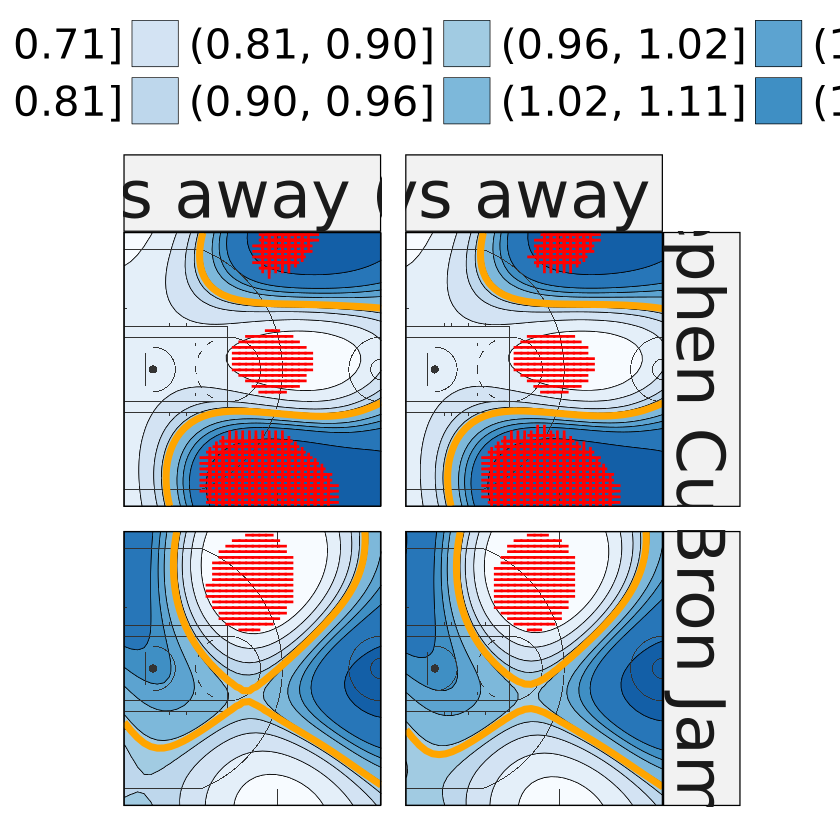

In [11]:
num_intervals = 10
digit_kept = 2
value_of_interest = plot_data_RR$RR
value_quantiles = quantile(value_of_interest, probs = seq(0, num_intervals)/num_intervals)
breaks = round(value_quantiles, digit_kept)
breaks[1] = floor(value_quantiles[1]*10^digit_kept)/10^digit_kept;  breaks[num_intervals+1] = ceiling(value_quantiles[num_intervals+1]*10^digit_kept)/10^digit_kept
breaks = unique(breaks)

breaks[1] = min(plot_data_RR$RR); breaks[length(breaks)] = max(plot_data_RR$RR)
ggshotintensity(intensity = plot_data_RR %>% 
                filter(player %in% c('Stephen Curry','LeBron James') & 
                      risk_name %in% c('home vs away (strong)','home vs away (weak)')), 
                x = "coord1", y = "coord2", 
                value_col = "RR", breaks = breaks, label_name = 'relative risk') +
                geom_text( data =  plot_data_RR %>% 
                                    filter(player %in% c('Stephen Curry','LeBron James') & 
                                          risk_name %in% c('home vs away (strong)','home vs away (weak)')),
                      aes(x = coord1, y = coord2, label = ifelse(cred_val == 1, "+", ifelse(cred_val == -1, "-", ""))),
                          vjust = 0.5, hjust = 0.5, color = "red",size = 7) +
  geom_tile() +
  facet_grid(rows = vars(player), cols=vars(risk_name)) +
  theme(axis.ticks = element_blank(), axis.text = element_blank()) +
  theme(legend.key.size = unit(1, 'cm'),legend.title = element_text(size=40),legend.text = element_text(size=25)) +
            theme(strip.text=element_text(size=40)) + theme(panel.spacing = unit(1, 'lines')) 

# Save the plot
ggsave(filename = 'Figures/shot_RR_Fig3.pdf', width = 15, height = 15)

## Figure4

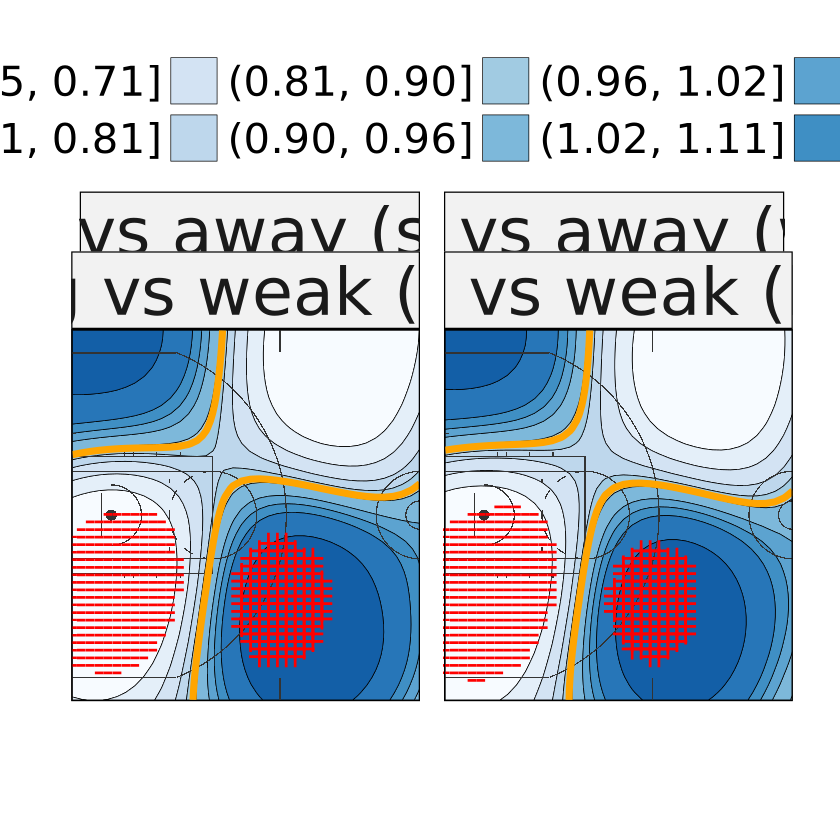

In [12]:
plot1 = ggshotintensity(intensity = plot_data_RR %>% 
                filter(player %in% c('Michael Jordan') & 
                      risk_name %in% c('home vs away (strong)','home vs away (weak)')), 
                x = "coord1", y = "coord2", 
                value_col = "RR", breaks = breaks, label_name = 'relative risk') +
                geom_text( data =  plot_data_RR %>% 
                                    filter(player %in% c('Michael Jordan') & 
                                          risk_name %in% c('home vs away (strong)','home vs away (weak)')),
                      aes(x = coord1, y = coord2, label = ifelse(cred_val == 1, "+", ifelse(cred_val == -1, "-", ""))),
                          vjust = 0.5, hjust = 0.5, color = "red",size = 7) +
  geom_tile() +
  facet_grid(cols = vars(risk_name)) +
  theme(axis.ticks = element_blank(), axis.text = element_blank()) +
  theme(legend.key.size = unit(1, 'cm'),legend.title = element_text(size=40),legend.text = element_text(size=25)) +
            theme(strip.text=element_text(size=40)) + theme(panel.spacing = unit(1, 'lines')) +
  theme(plot.margin = unit(c(1, 1, -5, 1), "cm"))

plot2 = ggshotintensity(intensity = plot_data_RR %>% 
                filter(player %in% c('Michael Jordan') & 
                      !(risk_name %in% c('home vs away (strong)','home vs away (weak)'))), 
                x = "coord1", y = "coord2", 
                value_col = "RR", breaks = breaks, label_name = 'relative risk') +
                geom_text( data =  plot_data_RR %>% 
                                    filter(player %in% c('Michael Jordan') & 
                                          !(risk_name %in% c('home vs away (strong)','home vs away (weak)'))),
                      aes(x = coord1, y = coord2, label = ifelse(cred_val == 1, "+", ifelse(cred_val == -1, "-", ""))),
                          vjust = 0.5, hjust = 0.5, color = "red",size = 7) +
  geom_tile() +
  facet_grid(cols = vars(risk_name)) +
  theme(axis.ticks = element_blank(), axis.text = element_blank()) +
  theme(legend.position = 'none') +
            theme(strip.text=element_text(size=40)) + theme(panel.spacing = unit(1, 'lines')) +
  theme(plot.margin = unit(c(-5, 1, 1, 1), "cm"))

plot_all = grid.arrange(plot1, plot2, ncol=1)
# Save the plot
ggsave(plot_all, filename = 'Figures/shot_RR_Fig4.pdf', width = 15, height = 22)

## Figure 5 (now in supp)

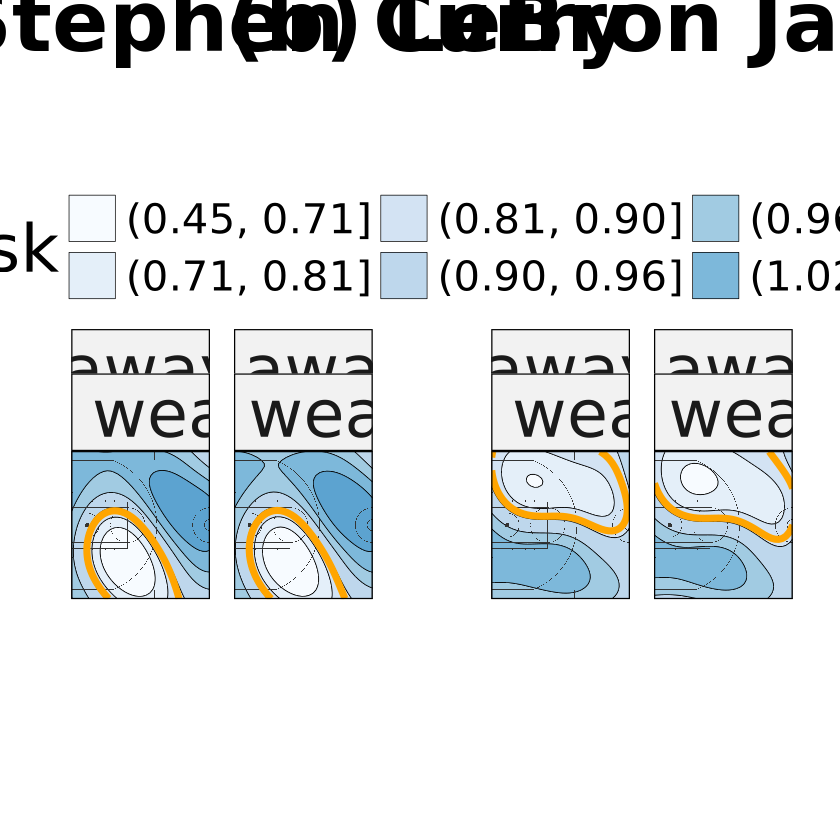

In [13]:
plot1 = ggshotintensity(intensity = plot_data_RR %>% 
                filter(player %in% c('Stephen Curry') & 
                      risk_name %in% c('home vs away (strong)','home vs away (weak)')), 
                x = "coord1", y = "coord2", 
                value_col = "RR", breaks = breaks, label_name = 'relative risk') +
                geom_text( data =  plot_data_RR %>% 
                                    filter(player %in% c('Stephen Curry') & 
                                          risk_name %in% c('home vs away (strong)','home vs away (weak)')),
                      aes(x = coord1, y = coord2, label = ifelse(cred_val == 1, "+", ifelse(cred_val == -1, "-", ""))),
                          vjust = 0.5, hjust = 0.5, color = "red",size = 7) +
  geom_tile() +
  facet_grid(cols = vars(risk_name)) +
  theme(axis.ticks = element_blank(), axis.text = element_blank()) +
  theme(legend.key.size = unit(1, 'cm'),legend.title = element_text(size=40),legend.text = element_text(size=25)) +
            theme(strip.text=element_text(size=40)) + theme(panel.spacing = unit(1, 'lines')) +
  theme(plot.margin = unit(c(1, 1, -5, 1), "cm"))

plot2 = ggshotintensity(intensity = plot_data_RR %>% 
                filter(player %in% c('Stephen Curry') & 
                      !(risk_name %in% c('home vs away (strong)','home vs away (weak)'))), 
                x = "coord1", y = "coord2", 
                value_col = "RR", breaks = breaks, label_name = 'relative risk') +
                geom_text( data =  plot_data_RR %>% 
                                    filter(player %in% c('Stephen Curry') & 
                                          !(risk_name %in% c('home vs away (strong)','home vs away (weak)'))),
                      aes(x = coord1, y = coord2, label = ifelse(cred_val == 1, "+", ifelse(cred_val == -1, "-", ""))),
                          vjust = 0.5, hjust = 0.5, color = "red",size = 7) +
  geom_tile() +
  facet_grid(cols = vars(risk_name)) +
  theme(axis.ticks = element_blank(), axis.text = element_blank()) +
  theme(legend.position = 'none') +
            theme(strip.text=element_text(size=40)) + theme(panel.spacing = unit(1, 'lines')) +
  theme(plot.margin = unit(c(-5, 1, 1, 1), "cm"))


plot3 = ggshotintensity(intensity = plot_data_RR %>% 
                filter(player %in% c('LeBron James') & 
                      risk_name %in% c('home vs away (strong)','home vs away (weak)')), 
                x = "coord1", y = "coord2", 
                value_col = "RR", breaks = breaks, label_name = 'relative risk') +
                geom_text( data =  plot_data_RR %>% 
                                    filter(player %in% c('LeBron James') & 
                                          risk_name %in% c('home vs away (strong)','home vs away (weak)')),
                      aes(x = coord1, y = coord2, label = ifelse(cred_val == 1, "+", ifelse(cred_val == -1, "-", ""))),
                          vjust = 0.5, hjust = 0.5, color = "red",size = 7) +
  geom_tile() +
  facet_grid(cols = vars(risk_name)) +
  theme(axis.ticks = element_blank(), axis.text = element_blank()) +
  theme(legend.key.size = unit(1, 'cm'),legend.title = element_text(size=40),legend.text = element_text(size=25)) +
            theme(strip.text=element_text(size=40)) + theme(panel.spacing = unit(1, 'lines')) +
  theme(plot.margin = unit(c(1, 1, -5, 1), "cm"))

plot4 = ggshotintensity(intensity = plot_data_RR %>% 
                filter(player %in% c('LeBron James') & 
                      !(risk_name %in% c('home vs away (strong)','home vs away (weak)'))), 
                x = "coord1", y = "coord2", 
                value_col = "RR", breaks = breaks, label_name = 'relative risk') +
                geom_text( data =  plot_data_RR %>% 
                                    filter(player %in% c('LeBron James') & 
                                          !(risk_name %in% c('home vs away (strong)','home vs away (weak)'))),
                      aes(x = coord1, y = coord2, label = ifelse(cred_val == 1, "+", ifelse(cred_val == -1, "-", ""))),
                          vjust = 0.5, hjust = 0.5, color = "red",size = 7) +
  geom_tile() +
  facet_grid(cols = vars(risk_name)) +
  theme(axis.ticks = element_blank(), axis.text = element_blank()) +
  theme(legend.position = 'none') +
            theme(strip.text=element_text(size=40)) + theme(panel.spacing = unit(1, 'lines')) +
  theme(plot.margin = unit(c(-5, 1, 1, 1), "cm"))

# Create titles
title1 <- textGrob("(a) Stephen Curry", gp=gpar(fontsize=50, fontface="bold"), just = "center")
title2 <- textGrob("(b) LeBron James", gp=gpar(fontsize=50, fontface="bold"), just = "center")

# Combine titles and plots
col1 <- arrangeGrob(title1, plot1, plot2, ncol = 1, heights = c(0.1, 1, 1))
col2 <- arrangeGrob(title2, plot3, plot4, ncol = 1, heights = c(0.1, 1, 1))

# Arrange the columns
plot_all <- grid.arrange(col1, col2, ncol = 2)

# Save the plot
ggsave(plot_all, filename = 'Figures/shot_RR_Fig5.pdf', width = 30, height = 23)
# plot_all = grid.arrange(plot1, plot3, plot2, plot4,  ncol=2)
# # Save the plot
# ggsave(plot_all, filename = 'Figures/shot_RR_Fig5.pdf', width = 30, height = 22)

# Traceplot

In [15]:
library(readxl)
library(devtools)
library(dplyr)
library(ggbasketball)
library(orthopolynom)
library(mvtnorm)
library(combinat)
library(lattice)
library(gridExtra)
library(grid) 
library(patchwork)
plot_trace = function(df, math_label = TRUE, nrow = NULL, ncol = NULL){
    if(math_label){
        ggplot(df) + geom_path(aes(x = iter, y = value), color = 'red') + 
                facet_wrap(variable ~ ., scales = 'free_y', labeller = label_parsed, nrow = nrow, ncol = ncol) +
                labs(x = 'Sampling Iteration', y =  "Posterior Samples")+ 
                theme(legend.key.size = unit(1, 'cm'),legend.title = element_text(size=20),legend.text = element_text(size=15)) +
                theme(axis.text=element_text(size=20),axis.title=element_text(size=25)) + 
                theme(strip.text=element_text(size=20)) + scale_alpha_manual(values=c(1,0.5)) + theme(panel.spacing = unit(1, 'lines'))    
    }else{
        ggplot(df) + geom_path(aes(x = iter, y = value), color = 'red') + 
                facet_wrap(variable ~ ., scales = 'free_y', labeller = label_parsed, nrow = nrow, ncol = ncol) +
                labs(x = 'Sampling Iteration', y =  "Posterior Samples")+ 
                theme(legend.key.size = unit(1, 'cm'),legend.title = element_text(size=20),legend.text = element_text(size=15)) +
                theme(axis.text=element_text(size=20),axis.title=element_text(size=25)) + 
                theme(strip.text=element_text(size=20)) + scale_alpha_manual(values=c(1,0.5)) + theme(panel.spacing = unit(1, 'lines'))    
        
        
    }

}
player_list = c('curry', 'jordan', 'james')
plot_data_intensity <- data.frame()
plot_data_probability <- data.frame()
plot_data_RR <- data.frame()
df_all <- data.frame()
for(player in player_list)
{
    source('../Code/basket_func_same.R')
    
    load(file=sprintf('../Data/%s_homelevel_theta.RData',player))  # Theta.result: 15000*15*7
    
    df = data.frame(value = as.vector(Theta.result[10001:15000,1,c(2,5)]),
                    iter = seq(5000), variable = rep( c("theta[0*','*1*','*1]^beta","theta[1*','*1*','*1]^beta") ,each = 5000 ),
                   player = player)
    df_all = rbind(df_all, df)
    # # 
}
df_all$player = factor(df_all$player, levels = c('curry','james','jordan'))
levels(df_all$player) = c('Stephen Curry', 'LeBron James','Michael Jordan')

In [ ]:
plot_trace = function (df, math_label = TRUE, nrow = NULL, ncol = NULL) 
{
    if (math_label) {
        ggplot(df) + geom_path(aes(x = iter, y = value), color = "red") + 
            facet_grid(rows = vars(variable), cols = vars(player), scales = "free_y", labeller = labeller(
                variable = label_parsed,  # parse math expressions for variable
                player = label_value      # keep player labels as plain text
              )
               ) + labs(x = "Sampling Iteration", 
            y = "Posterior Samples") + theme(legend.key.size = unit(1, 
            "cm"), legend.title = element_text(size = 25), legend.text = element_text(size = 20)) + 
            theme(axis.text = element_text(size = 20), axis.title = element_text(size = 25)) + 
            theme(strip.text.x = element_text(size = 24), strip.text.y = element_text(size = 22), panel.spacing = unit(1, "lines")) + scale_alpha_manual(values = c(1, 
            0.5))  + theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
}
plot_trace(df_all, math_label = TRUE)
ggsave(filename = 'Figures/traceplot_supp.pdf', width = 13, height = 11)

# Shot Scatter Plot

In [7]:
library(RandomFields)
library(fields)
library(orthopolynom)
library(mvtnorm)
library(combinat)
library(lattice)
library(Matrix)
library(ggplot2)
library(tidyverse)
library(doParallel)
library(foreach)
library(ggpubr)
library(ggbasketball)

Loading required package: sp

Loading required package: RandomFieldsUtils

Consider the use of one of 
	RFoptions(install.control=list(force=FALSE))
	RFoptions(install.control=list(repos=NULL))
	RFoptions(install.control=NULL)
If you use it, the package might run faster the next time it is loaded.
Recompilation is at your own risk. There is currently no guarantee that it will work.
In case of problems:  Please contact the maintainer martin.schlather@math.uni-mannheim.de.



Attaching package: ‘RandomFields’


The following objects are masked from ‘package:RandomFieldsUtils’:

    checkExamples, RFoptions


Loading required package: spam

Spam version 2.11-3 (2026-01-05) is loaded.
Type 'help( Spam)' or 'demo( spam)' for a short introduction 
and overview of this package.
Help for individual functions is also obtained by adding the
suffix '.spam' to the function name, e.g. 'help( chol.spam)'.


Attaching package: ‘spam’


The following objects are masked from ‘package:base’:

    backso

In [9]:
# Load data
# -------------------------------------

shot_data_ALL = data.frame()
setting_list = c('jordan','curry','james')
for(setting in setting_list){
    covar2<-read.table(sprintf("../Data/%s_covariates.txt",setting),header=TRUE)
    
    home = away = rep(0, nrow(covar2))
    home[covar2$home==1] = 1
    away[covar2$home==2] = 1

    level = abs(covar2$level - 2)
    covar = data.frame(game = covar2$game, home, away, level = level)
    if(setting != 'jordan'){
        shot_data = read.table(sprintf("../Data/del_%s.txt",setting),header=TRUE)
        shot_data[, 3] = shot_data[, 3]/250 
        shot_data[, 4] = shot_data[, 4]/235 - 39/47
    
    }else{
        shot_data = read.table("../Data/jordan_data.txt",header=TRUE)
        bigid = which(shot_data[,6]>28)
        smallid = which(shot_data[, 6]<1)

        shot_data = shot_data[-c(smallid,bigid), ]
        shot_data[, 4] = shot_data[, 4]/300 - 1
        shot_data[, 5] = shot_data[, 5]/235 - 1
    }
     
    # --------------------# --------------------# --------------------
    # Prepar training data
    shot_data = cbind(shot_data, covar[shot_data$Game,c('home','away','level')])
    shot_data = shot_data %>% select(c("Game","Missmade","Xdist","Ydist","Dist","home","away","level"))

    coords_x = 23.5*(shot_data$Ydist+1)
    coords_y = 25*shot_data$Xdist
    shot_data$Xdist = coords_x
    shot_data$Ydist = coords_y
    shot_data$player = setting
    
    shot_data_ALL = rbind(shot_data_ALL, shot_data)
}

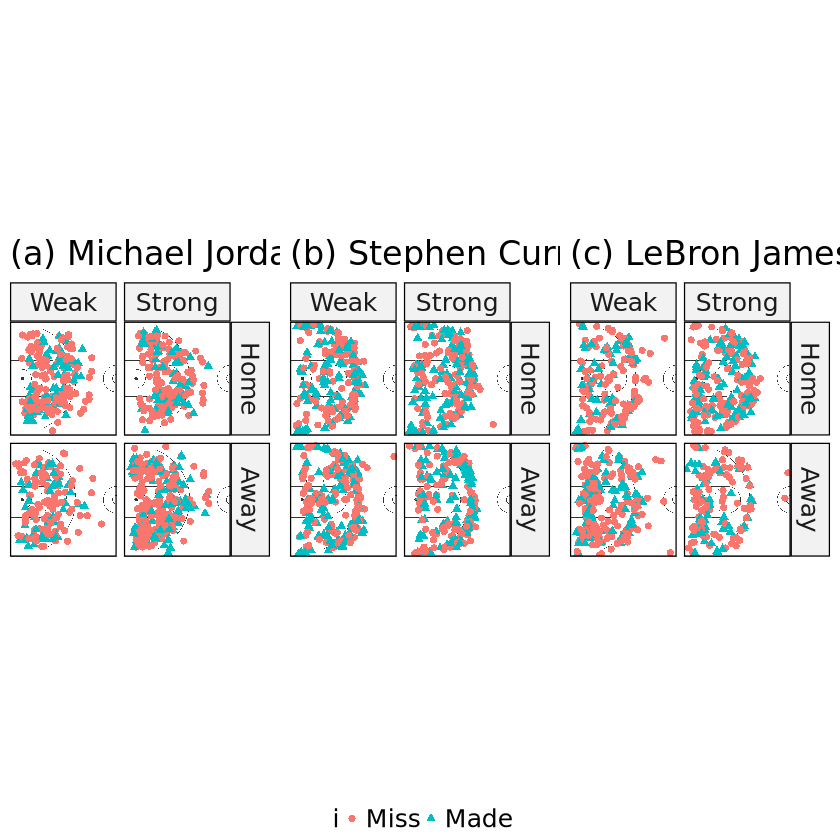

In [10]:
cols_to_factor <- c("Game", "Missmade", "home", "away", "level", "player")
shot_data_ALL[cols_to_factor] <- lapply(shot_data_ALL[cols_to_factor], as.factor)
levels(shot_data_ALL$Missmade) = c('Miss','Made')
levels(shot_data_ALL$home) = c('Home','Away')
levels(shot_data_ALL$level) = c('Weak','Strong')

shot_data_ALL$i <- shot_data_ALL$Missmade

p1 = ggshotchart(shot_data_ALL %>% filter(player == "jordan"),  x = "Xdist", y = "Ydist", result = "i") +
      facet_grid(rows = vars(home), cols=vars(level)) +
      theme(axis.ticks = element_blank(), axis.text = element_blank()) + 
      labs(title = "(a) Michael Jordan") + theme(plot.title = element_text(size=20)) + 
      theme(legend.key.size = unit(0.1, 'cm'),legend.title = element_text(size=15),legend.text = element_text(size=15)) +
                theme(strip.text=element_text(size=15)) + theme(panel.spacing = unit(0.3, 'lines')) 

p2 = ggshotchart(shot_data_ALL %>% filter(player == "curry"),  x = "Xdist", y = "Ydist", result = "i") +
      facet_grid(rows = vars(home), cols=vars(level)) + 
      theme(axis.ticks = element_blank(), axis.text = element_blank()) +
      labs(title = "(b) Stephen Curry") + theme(plot.title = element_text(size=20)) + 
      theme(legend.key.size = unit(0.1, 'cm'),legend.title = element_text(size=15),legend.text = element_text(size=15)) +
                theme(strip.text=element_text(size=15)) + theme(panel.spacing = unit(0.3, 'lines')) 

p3 = ggshotchart(shot_data_ALL %>% filter(player == "james"),  x = "Xdist", y = "Ydist", result = "i") +
      facet_grid(rows = vars(home), cols=vars(level)) + 
      theme(axis.ticks = element_blank(), axis.text = element_blank()) +
      labs(title = "(c) LeBron James") + theme(plot.title = element_text(size=20)) + 
      theme(legend.key.size = unit(0.1, 'cm'),legend.title = element_text(size=15),legend.text = element_text(size=15)) +
                theme(strip.text=element_text(size=15)) + theme(panel.spacing = unit(0.3, 'lines')) 

ggarrange(p1, p2, p3, nrow = 1, ncol = 3, common.legend = TRUE, legend = "bottom")  
ggsave(file = "Figures/Shotchart.pdf", width = 12, height = 5)
# p1 = ggarrange(p_c, p_pf, p_pg, nrow = 1, ncol = 3, common.legend = FALSE)
        # p2 = ggarrange(p_sf, p_sg, nrow = 1, ncol = 2, common.legend = TRUE, legend = "bottom")
        # plot_grid(p1, p2, p3, ncol = 1)